# IGF1R / calx-β — MM-GBSA binding free energy (post-MD)

Follow-up to [`igf1r3qqu_calxbeta_gromacs_md.ipynb`](igf1r3qqu_calxbeta_gromacs_md.ipynb).

Reads saved production MD artifacts from `data/md_calx_3qqu/` (via `md_results_manifest.json`) and estimates:

$$\Delta G_{\mathrm{bind}} \approx \langle G_{\mathrm{complex}} \rangle - \langle G_{\mathrm{receptor}} \rangle - \langle G_{\mathrm{ligand}} \rangle$$

using **MM-GBSA** (Generalized Born implicit solvent) through **[gmx_MMPBSA](https://valdes-tresanco-ms.github.io/gmx_MMPBSA/)** — the standard tool for **GROMACS + AMBER force field** trajectories (`amber99sb-ildn` in our pipeline).

## Pipeline steps in this notebook

1. Load MD manifest + validate `md.tpr`, `md.xtc`, `topol.top`
2. **Extract / subsample frames** (`gmx trjconv` writes **Protein only** to `/tmp`, then copies once to `data/`)
3. **Define receptor vs ligand** index groups (receptor = all protein chains except **B**; ligand = chain **B** / calx-β)
4. Run **gmx_MMPBSA** (GBSA; PBSA optional via config) in `/tmp`
5. Report **mean ΔG_bind ± uncertainty** (std error across frames + bootstrap 95% CI)

## 30 ns production — do not load `System` into Python

The production xtc is **protein + all water** (`compressed-x-grps = System`, ~48 710 atoms, one frame every 10 ps). Loading that with `md.load` or writing it again through **gcsfuse** (`/workspace`) can hang or kill the Jupyter kernel.

This notebook therefore:

- never loads the full solvated trajectory into RAM
- writes the MMPBSA xtc under **`/tmp`** (local disk), then copies the finished file
- keeps **Protein** only (receptor + calx-β, ~2847 atoms). MM-GBSA uses implicit solvent, so water in the xtc is unused
- strides frames (`TRJCONV_DT_PS = 100` ps → ~301 frames from 30 ns)
- runs **gmx_MMPBSA MPI** on all VM CPUs (`mpirun -np`); decomposition is off (`RUN_DECOMP = False`) so only mean ΔG is computed

Production MD does **not** need to be run again. Use existing `md.tpr` / `md.xtc` (and `md_pbc.xtc` if it covers the full 30 ns).

## Tooling notes

| Tool | Status for this project |
|------|-------------------------|
| **gmx_MMPBSA** | **Recommended** — native GROMACS topology/trajectory |
| `g_mmpbsa` | Legacy, unmaintained; not in GROMACS 2025 |
| **AmberTools `MMPBSA.py`** | Possible but requires converting GROMACS → AMBER topology; not used here |

**Dependencies (one-time in the MD container):** dedicated env `gmxMMPBSA` (do not install into the Jupyter kernel — it is Python 3.14 / NumPy 2.x).

```bash
mamba create -n gmxMMPBSA python=3.11 -y
mamba install -n gmxMMPBSA -c conda-forge ambertools=24.8 gmx_mmpbsa mpi4py -y
```

On linux-aarch64 (this image), AmberTools starts at **24.8**. Re-run the install cell below; it creates the env if missing.

## Important caveats

- MM-GBSA is **approximate** (implicit solvent, limited entropy; useful for **comparing poses**, not experimental Kd without calibration).
- **Short trajectories** (e.g. 10 ps) give **noisy** averages — prefer **≥10–100 ns** production MD before trusting numbers.
- First run can take **tens of minutes** (one implicit-solvent calculation per frame per species). MPI splits frames across CPUs; turn `RUN_DECOMP = True` only if you need a per-residue map (much slower).

In [1]:
from __future__ import annotations

import json
import re
import shutil
import subprocess
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def resolve_data_dir() -> Path:
    for candidate in (
        Path("../data"),
        Path("/workspace/data"),
        Path("data"),
    ):
        if (candidate / "md_calx_3qqu").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not find data/md_calx_3qqu — run the GROMACS notebook first.")


DATA_DIR = resolve_data_dir()
MD_ROOT = DATA_DIR / "md_calx_3qqu"
MANIFEST_PATH = MD_ROOT / "md_results_manifest.json"

print(f"MD work dir: {MD_ROOT}")
print(f"Manifest:    {MANIFEST_PATH} ({'found' if MANIFEST_PATH.exists() else 'missing'})")

MD work dir: /workspace/repos/tomo_2026b/md/data/md_calx_3qqu
Manifest:    /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/md_results_manifest.json (found)


In [2]:
# --- Configuration ---
LIGAND_CHAIN = "B"  # calx-β in pocket_calx_3qqu.pdb / topol_Protein_chain_B.itp

RUN_MMPBSA = True  # False = prepare inputs only (index, subsampled xtc, input file)
FORCE_REEXTRACT = False  # True = rebuild mmpbsa.xtc even if it already exists

# GROMACS -b / -dt are in picoseconds (not ns). Production xtc is already 10 ps.
# 100 ps → ~301 frames from 30 ns. None = keep every saved frame (too many for GBSA).
TRJCONV_DT_PS: float | None = 100.0
TRJCONV_START_PS = 0.0  # skip this many ps at the start of production if desired
# Protein = receptor + calx-β. Do not use System (all water); GBSA does not need it.
TRJCONV_OUTPUT_GROUP = "Protein"

# gmx_MMPBSA settings
MMPBSA_METHOD = "gbsa"  # "gbsa" or "pbsa" (PBSA is slower)
GB_IGB = 5  # 5 = GBn2 (common for proteins); 2 = OBC2
SALT_CONC_M = 0.150  # match MD ion concentration
FORCEFIELD = "amber99sb-ildn"
RUN_DECOMP = False  # True = per-residue decomp (idecomp=2); much slower, not needed for mean ΔG
# None = all VM CPUs (capped at frame count). Set an int to pin the rank count.
MMPBSA_MPI_NPROCS: int | None = None

MMPBSA_DIR = MD_ROOT / "mmpbsa"
MMPBSA_DIR.mkdir(parents=True, exist_ok=True)
# Local disk. gcsfuse (/workspace) hangs on many small xtc writes; copy once when done.
TMP_MMPBSA_DIR = Path("/tmp/md_calx_3qqu_mmpbsa")
TMP_MMPBSA_DIR.mkdir(parents=True, exist_ok=True)

SUBSAMPLED_XTC = MMPBSA_DIR / "mmpbsa.xtc"
COMPLEX_TPR = MMPBSA_DIR / "complex.tpr"  # Protein-only tpr; must match mmpbsa.xtc atom count
INDEX_NDX = MMPBSA_DIR / "mmpbsa.ndx"
INPUT_IN = MMPBSA_DIR / "mmpbsa.in"
RESULTS_PREFIX = MMPBSA_DIR / "FINAL_RESULTS_MMPBSA"
RESULTS_DAT = MMPBSA_DIR / "FINAL_RESULTS_MMPBSA.dat"
RESULTS_CSV = MMPBSA_DIR / "FINAL_RESULTS_MMPBSA.csv"
RESULTS_MANIFEST = MMPBSA_DIR / "mmpbsa_results_manifest.json"

print(
    f"MMPBSA extract: group={TRJCONV_OUTPUT_GROUP}  dt={TRJCONV_DT_PS} ps  "
    f"tmp={TMP_MMPBSA_DIR}  force_reextract={FORCE_REEXTRACT}  "
    f"decomp={RUN_DECOMP}  mpi_nprocs={MMPBSA_MPI_NPROCS or 'all CPUs'}"
)

MMPBSA extract: group=Protein  dt=100.0 ps  tmp=/tmp/md_calx_3qqu_mmpbsa  force_reextract=False  decomp=False  mpi_nprocs=all CPUs


In [3]:
def load_md_manifest(path: Path = MANIFEST_PATH) -> dict:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run the GROMACS notebook through save_md_results_manifest()."
        )
    return json.loads(path.read_text())


def resolve_artifact(manifest: dict, key: str, default_name: str) -> Path:
    """Resolve manifest paths (handles stale /workspace vs local paths)."""
    default = MD_ROOT / default_name
    raw = manifest.get(key)
    if not raw:
        return default
    stored = Path(raw)
    if stored.exists():
        return stored
    fallback = MD_ROOT / stored.name
    if fallback.exists():
        return fallback
    return default


@dataclass(frozen=True)
class MdInputs:
    tpr: Path
    xtc: Path
    top: Path
    gro: Path


manifest = load_md_manifest()
pbc_xtc = resolve_artifact(manifest, "pbc_trajectory", "md_pbc.xtc")
prod_xtc = resolve_artifact(manifest, "trajectory", "md.xtc")
if not prod_xtc.exists():
    prod_xtc = MD_ROOT / "md.xtc"

# Prefer PBC-corrected xtc only if it is not a leftover short run (e.g. 1 ns md_pbc vs 30 ns md.xtc).
if pbc_xtc.exists() and prod_xtc.exists():
    pbc_sz = pbc_xtc.stat().st_size
    prod_sz = prod_xtc.stat().st_size
    if pbc_sz >= 0.8 * prod_sz:
        xtc_path = pbc_xtc
    else:
        xtc_path = prod_xtc
        print(
            f"Using {prod_xtc.name} ({prod_sz / 1e6:.0f} MB); "
            f"{pbc_xtc.name} is much smaller ({pbc_sz / 1e6:.0f} MB) — leftover short run."
        )
elif pbc_xtc.exists():
    xtc_path = pbc_xtc
else:
    xtc_path = prod_xtc
if not xtc_path.exists():
    xtc_path = MD_ROOT / "md.xtc"

inputs = MdInputs(
    tpr=MD_ROOT / "md.tpr",
    xtc=xtc_path,
    top=MD_ROOT / "topol.top",
    gro=resolve_artifact(manifest, "topology", "npt.gro"),
)

def xtc_frame_summary(path: Path) -> tuple[int, float]:
    """Return (n_frames, last_time_ps) via gmx check. Does not load coordinates into Python RAM."""
    cmd = ["gmx", "check", "-f", str(path)]
    print("$", " ".join(cmd), flush=True)
    result = subprocess.run(cmd, capture_output=True, text=True, check=False)
    text = (result.stdout or "") + "\n" + (result.stderr or "")
    last = re.search(r"Last frame\s+(\d+)\s+time\s+([\d.]+)", text, flags=re.I)
    coords = re.search(r"^\s*Coords\s+(\d+)", text, flags=re.M)
    if coords:
        n_frames = int(coords.group(1))
    elif last:
        n_frames = int(last.group(1)) + 1  # GROMACS prints a 0-based last frame index
    else:
        raise RuntimeError(f"gmx check did not report a frame count for {path}:\n{text[-2000:]}")
    last_ps = float(last.group(2)) if last else 0.0
    return n_frames, last_ps


def xtc_times(path: Path) -> np.ndarray:
    """Read frame times (ps). Discards coordinates so the full xtc is not kept in RAM."""
    from mdtraj.formats import XTCTrajectoryFile

    chunks: list[np.ndarray] = []
    with XTCTrajectoryFile(str(path)) as fh:
        while True:
            _xyz, time, _step, _box = fh.read(n_frames=500)
            if time is None or len(time) == 0:
                break
            chunks.append(np.asarray(time, dtype=float))
    return np.concatenate(chunks) if chunks else np.array([], dtype=float)


missing = [p for p in (inputs.tpr, inputs.xtc, inputs.top, inputs.gro) if not p.exists()]
if missing:
    raise FileNotFoundError("Missing MD inputs: " + ", ".join(str(p) for p in missing))

n_src_frames, last_src_ps = xtc_frame_summary(inputs.xtc)
traj_ps = last_src_ps

print(f"Production TPR:  {inputs.tpr}")
print(f"Structure (gro): {inputs.gro}")
print(f"Trajectory:      {inputs.xtc}  ({n_src_frames} frames, last {traj_ps:.1f} ps)")
print(f"Topology:        {inputs.top}")
print(f"Manifest saved:  {manifest.get('saved_at', '?')}")
if traj_ps < 1000:
    print(
        "\n⚠ Trajectory < 1 ns — MM-GBSA will run but statistics will be unreliable. "
        "Re-run production MD with larger TOTAL_STEPS first."
    )
elif traj_ps < 10_000:
    print(
        f"\nNote: production length is {traj_ps/1000:.1f} ns. Prefer ≥10 ns before treating "
        "the MM-GBSA mean as more than qualitative."
    )

$ gmx check -f /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/md_pbc.xtc
Production TPR:  /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/md.tpr
Structure (gro): /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/npt.gro
Trajectory:      /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/md_pbc.xtc  (3001 frames, last 30000.0 ps)
Topology:        /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/topol.top
Manifest saved:  2026-08-17T10:10:16.836744+00:00


In [4]:
def run_gmx(args: list[str], *, cwd: Path = MD_ROOT, stdin: str | None = None) -> str:
    """Run gmx; stdin is closed immediately so trjconv cannot wait on the notebook.

    Stdout goes to a /tmp log (not gcsfuse, not capture_output in the kernel).
    """
    cmd = ["gmx", *args]
    print("$", " ".join(cmd), flush=True)
    TMP_MMPBSA_DIR.mkdir(parents=True, exist_ok=True)
    log_path = TMP_MMPBSA_DIR / "gmx_last.log"
    with log_path.open("w", encoding="utf-8") as log_fh:
        log_fh.write("$ " + " ".join(cmd) + "\n")
        log_fh.flush()
        proc = subprocess.Popen(
            cmd,
            cwd=cwd,
            stdin=subprocess.PIPE,
            stdout=log_fh,
            stderr=subprocess.STDOUT,
            text=True,
        )
        assert proc.stdin is not None
        if stdin is not None:
            proc.stdin.write(stdin)
        proc.stdin.close()
        returncode = proc.wait()
    text = log_path.read_text(encoding="utf-8", errors="replace")
    if text:
        print(text[-2000:], flush=True)
    if returncode != 0:
        raise RuntimeError(f"gmx failed ({returncode}): {text[-4000:]}")
    return text


def _rel_to_md(path: Path) -> str:
    try:
        return str(path.relative_to(MD_ROOT))
    except ValueError:
        return str(path)


def _extract_is_current() -> bool:
    """Reuse only a Protein-only extract that is newer than the source xtc.

    The old 1 ns run wrote mmpbsa.xtc (System, 101 frames) without complex.tpr.
    Requiring complex.tpr forces a rebuild after 30 ns production.
    """
    if FORCE_REEXTRACT:
        return False
    if not SUBSAMPLED_XTC.exists() or not COMPLEX_TPR.exists():
        return False
    if SUBSAMPLED_XTC.stat().st_size < 10_000:
        return False
    if SUBSAMPLED_XTC.stat().st_mtime < inputs.xtc.stat().st_mtime:
        return False
    return True


def extract_frames_for_mmpbsa() -> Path:
    """Protein-only, strided xtc on local disk, then one copy to the workspace."""
    if _extract_is_current():
        print(f"Reusing {SUBSAMPLED_XTC} and {COMPLEX_TPR}")
        return SUBSAMPLED_XTC

    TMP_MMPBSA_DIR.mkdir(parents=True, exist_ok=True)
    tmp_xtc = TMP_MMPBSA_DIR / "mmpbsa.xtc"
    tmp_tpr = TMP_MMPBSA_DIR / "complex.tpr"
    if tmp_xtc.exists():
        tmp_xtc.unlink()
    if tmp_tpr.exists():
        tmp_tpr.unlink()

    trjconv_args = ["trjconv", "-s", "md.tpr", "-f", _rel_to_md(inputs.xtc)]
    if TRJCONV_START_PS > 0:
        trjconv_args += ["-b", str(TRJCONV_START_PS)]  # picoseconds
    if TRJCONV_DT_PS is not None:
        trjconv_args += ["-dt", str(TRJCONV_DT_PS)]  # picoseconds
    trjconv_args += [
        "-pbc", "mol",
        "-center",
        "-ur", "compact",
        "-o", str(tmp_xtc),
    ]
    print(
        f"Writing {TRJCONV_OUTPUT_GROUP}-only xtc to {tmp_xtc} (local /tmp, not gcsfuse).",
        flush=True,
    )
    # Two prompts: centering group, then output group. Both Protein (no water).
    run_gmx(trjconv_args, stdin=f"Protein\n{TRJCONV_OUTPUT_GROUP}\n")

    # Matching tpr so gmx_MMPBSA atom counts agree with the stripped xtc.
    run_gmx(["convert-tpr", "-s", "md.tpr", "-o", str(tmp_tpr)], stdin=f"{TRJCONV_OUTPUT_GROUP}\n")

    MMPBSA_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copy2(tmp_xtc, SUBSAMPLED_XTC)
    shutil.copy2(tmp_tpr, COMPLEX_TPR)
    print(
        f"Copied {SUBSAMPLED_XTC.name} ({SUBSAMPLED_XTC.stat().st_size / 1e6:.1f} MB) "
        f"and {COMPLEX_TPR.name} → {MMPBSA_DIR}",
        flush=True,
    )
    return SUBSAMPLED_XTC


@dataclass
class TrajMeta:
    n_frames: int
    time: np.ndarray  # ps; used only for the per-frame plot


xtc_for_mmpbsa = extract_frames_for_mmpbsa()
n_mmpbsa_frames, last_mmpbsa_ps = xtc_frame_summary(xtc_for_mmpbsa)
times = xtc_times(xtc_for_mmpbsa)
traj = TrajMeta(
    n_frames=int(len(times) if len(times) else n_mmpbsa_frames),
    time=times,
)
print(
    f"MMPBSA trajectory: {xtc_for_mmpbsa.name} — {traj.n_frames} frames, "
    f"last {last_mmpbsa_ps:.1f} ps (Protein-only; not loaded into RAM)"
)

Reusing /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/mmpbsa/mmpbsa.xtc and /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/mmpbsa/complex.tpr
$ gmx check -f /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/mmpbsa/mmpbsa.xtc
MMPBSA trajectory: mmpbsa.xtc — 301 frames, last 30000.0 ps (Protein-only; not loaded into RAM)


In [5]:
def _itp_atom_count(itp_path: Path) -> int:
    """Count atoms in a GROMACS molecule .itp [ atoms ] section."""
    in_atoms = False
    count = 0
    for line in itp_path.read_text().splitlines():
        stripped = line.strip()
        if stripped.startswith("[ atoms ]"):
            in_atoms = True
            continue
        if in_atoms and stripped.startswith("["):
            break
        if in_atoms and re.match(r"\s*\d+\s+\S+", line):
            count += 1
    return count


def _protein_molecule_atom_range(molecule_name: str, *, top_path: Path = inputs.top) -> tuple[int, int]:
    """Inclusive 1-based GROMACS atom indices for a protein molecule in topol.top order."""
    section = None
    molecules: list[tuple[str, int]] = []
    for line in top_path.read_text().splitlines():
        stripped = line.strip()
        if stripped.startswith("[") and stripped.endswith("]"):
            section = stripped
            continue
        if section != "[ molecules ]" or not stripped or stripped.startswith(";"):
            continue
        parts = stripped.split()
        molecules.append((parts[0], int(parts[1])))

    atom_start = 1
    for name, mult in molecules:
        if not name.startswith("Protein_chain_"):
            continue
        itp = top_path.parent / f"topol_{name}.itp"
        if not itp.exists():
            raise FileNotFoundError(f"Missing topology include for {name}: {itp}")
        n_atoms = _itp_atom_count(itp) * mult
        atom_end = atom_start + n_atoms - 1
        if name == molecule_name:
            return atom_start, atom_end
        atom_start = atom_end + 1

    raise ValueError(
        f"Molecule {molecule_name!r} not found in {top_path.name}. "
        f"Available: {[n for n, _ in molecules if n.startswith('Protein_chain_')]}"
    )


def _write_ndx(path: Path, groups: dict[str, list[int]]) -> None:
    lines: list[str] = []
    for name, indices in groups.items():
        lines.append(f"[ {name} ]")
        for offset in range(0, len(indices), 15):
            chunk = indices[offset : offset + 15]
            lines.append(" ".join(f"{idx:5d}" for idx in chunk))
        lines.append("")
    path.write_text("\n".join(lines).rstrip() + "\n")


def parse_ndx_group_ids(ndx_path: Path) -> dict[str, int]:
    """Return 0-based GROMACS group index for each [ GroupName ] block.

    gmx make_ndx / gmx_MMPBSA -cg use the numbers shown in make_ndx
    (first group is 0). A 1-based ID here makes gmx_MMPBSA rename
    nonexistent groups and then fail in gmx trjconv.
    """
    groups: dict[str, int] = {}
    for line in ndx_path.read_text().splitlines():
        line = line.strip()
        if line.startswith("[") and line.endswith("]"):
            name = line[1:-1].strip()
            groups[name] = len(groups)
    return groups


def build_receptor_ligand_index(*, ligand_chain: str = LIGAND_CHAIN) -> tuple[Path, int, int]:
    """Receptor = all protein chains except calx-β (Protein_chain_{ligand_chain}).

    pdb2gmx drops PDB chain IDs in md.tpr, so chain-based make_ndx selections fail.
    Instead, map the ligand via topol.top molecule order (Protein_chain_B here).
    """
    ligand_molecule = f"Protein_chain_{ligand_chain}"
    lig_lo, lig_hi = _protein_molecule_atom_range(ligand_molecule)
    ligand_atoms = list(range(lig_lo, lig_hi + 1))
    receptor_atoms = list(range(1, lig_lo))

    if not ligand_atoms:
        raise RuntimeError(f"No atoms found for {ligand_molecule}")
    if not receptor_atoms:
        raise RuntimeError(f"No receptor atoms found before {ligand_molecule}")

    _write_ndx(INDEX_NDX, {"Receptor": receptor_atoms, "Ligand": ligand_atoms})
    groups = parse_ndx_group_ids(INDEX_NDX)
    if "Receptor" not in groups or "Ligand" not in groups:
        raise RuntimeError(f"Index groups missing — found: {list(groups)}")

    print(
        f"Ligand {ligand_molecule}: atoms {lig_lo}-{lig_hi} ({len(ligand_atoms)} atoms); "
        f"receptor: {len(receptor_atoms)} atoms"
    )
    return INDEX_NDX, groups["Receptor"], groups["Ligand"]


index_path, receptor_group, ligand_group = build_receptor_ligand_index()
print(f"Index: {index_path}")
print(f"gmx_MMPBSA -cg {receptor_group} {ligand_group}  (Receptor, Ligand)")

Ligand Protein_chain_B: atoms 939-2847 (1909 atoms); receptor: 938 atoms
Index: /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/mmpbsa/mmpbsa.ndx
gmx_MMPBSA -cg 0 1  (Receptor, Ligand)


In [6]:
def write_mmpbsa_input(*, n_frames: int) -> Path:
    endframe = max(1, n_frames)
    if MMPBSA_METHOD.lower() == "pbsa":
        solvation = f"""&pb
ipb=2, inp=1,
/"""
    else:
        solvation = f"""&gb
igb={GB_IGB}, saltcon={SALT_CONC_M},
/"""

    decomp = ""
    if RUN_DECOMP:
        # Presence of &decomp enables decomposition; idecomp must be 1–4 (0 is invalid).
        decomp = """
&decomp
idecomp=2, dec_verbose=1,
print_res="within 4",
/
"""

    # Do not set gmx_path: gmx_MMPBSA uses it as shutil.which(..., path=gmx_path)
    # for *all* tools (cpptraj, tleap, gmx). A value like 'gmx' hides AmberTools.
    text = f"""&general
startframe=1, endframe={endframe}, interval=1,
forcefields='{FORCEFIELD}',
PBRadii=4,
keep_files=0,
/
{solvation}
{decomp}"""
    INPUT_IN.write_text(text)
    decomp_note = " + decomp" if RUN_DECOMP else ""
    print(f"Wrote {INPUT_IN} ({MMPBSA_METHOD.upper()}{decomp_note}, {endframe} frames)")
    return INPUT_IN


write_mmpbsa_input(n_frames=traj.n_frames)

Wrote /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/mmpbsa/mmpbsa.in (GBSA, 301 frames)


PosixPath('/workspace/repos/tomo_2026b/md/data/md_calx_3qqu/mmpbsa/mmpbsa.in')

In [7]:
import os

# Dedicated env: do not pip-install into this Jupyter kernel (Python 3.14 / NumPy 2.x).
# gmx_MMPBSA + AmberTools 24.8 live in /opt/conda/envs/gmxMMPBSA (linux-aarch64).
MMPBSA_ENV = Path("/opt/conda/envs/gmxMMPBSA")
AUTO_INSTALL_MMPBSA = True


def _prepend_path(*dirs: Path) -> None:
    extra = [str(p) for p in dirs if p.is_dir()]
    if not extra:
        return
    current = os.environ.get("PATH", "")
    os.environ["PATH"] = os.pathsep.join([*extra, current])


def _activate_mmpbsa_env() -> None:
    """Put AmberTools + gmx on PATH and set AMBERHOME for this kernel process."""
    os.environ["AMBERHOME"] = str(MMPBSA_ENV)
    _prepend_path(Path("/opt/conda/envs/gromacs/bin"), MMPBSA_ENV / "bin")


def _find_gmx_mmpbsa() -> str | None:
    _activate_mmpbsa_env()
    return shutil.which("gmx_MMPBSA")


def _run_install(cmd: list[str]) -> None:
    print("$", " ".join(cmd), flush=True)
    result = subprocess.run(cmd, text=True, capture_output=True, check=False)
    if result.stdout:
        print(result.stdout[-3000:], flush=True)
    if result.returncode != 0:
        err = (result.stderr or result.stdout or "").strip()
        raise RuntimeError(f"install failed ({result.returncode}):\n{err[-6000:]}")


def ensure_gmx_mmpbsa(*, auto_install: bool = AUTO_INSTALL_MMPBSA) -> str:
    """Return gmx_MMPBSA executable, installing a dedicated conda env if needed."""
    exe = _find_gmx_mmpbsa()
    if exe:
        return exe

    hint = (
        "  mamba create -n gmxMMPBSA python=3.11 -y\n"
        "  mamba install -n gmxMMPBSA -c conda-forge ambertools=24.8 gmx_mmpbsa mpi4py -y\n"
        "  # linux-aarch64 has no AmberTools <24; 24.8 is the oldest ARM build"
    )
    if not auto_install:
        raise FileNotFoundError(f"gmx_MMPBSA not found. Install with:\n{hint}")

    mamba = shutil.which("mamba") or "/opt/conda/bin/mamba"
    if not Path(mamba).exists():
        raise FileNotFoundError(f"mamba not found at {mamba}. Install AmberTools manually:\n{hint}")

    print(
        "gmx_MMPBSA missing — creating dedicated env gmxMMPBSA "
        "(Python 3.11 + AmberTools). This can take several minutes…",
        flush=True,
    )
    if not (MMPBSA_ENV / "bin" / "python").exists():
        _run_install([mamba, "create", "-n", "gmxMMPBSA", "python=3.11", "-y"])
    _run_install(
        [
            mamba,
            "install",
            "-n",
            "gmxMMPBSA",
            "-c",
            "conda-forge",
            "ambertools=24.8",
            "gmx_mmpbsa",
            "mpi4py",
            "-y",
        ]
    )

    exe = _find_gmx_mmpbsa()
    if not exe:
        raise FileNotFoundError(f"Install finished but gmx_MMPBSA is still not on PATH.\n{hint}")
    return exe


GMX_MMPBSA_EXE = ensure_gmx_mmpbsa()
cpptraj = shutil.which("cpptraj")
if not cpptraj:
    raise FileNotFoundError(
        f"gmx_MMPBSA is installed but cpptraj is not on PATH. "
        f"Expected {MMPBSA_ENV / 'bin' / 'cpptraj'}"
    )
print(f"Using: {GMX_MMPBSA_EXE}")
print(f"cpptraj: {cpptraj}")
print(f"gmx: {shutil.which('gmx')}")
print(f"AMBERHOME: {os.environ.get('AMBERHOME')}")

Using: /opt/conda/envs/gmxMMPBSA/bin/gmx_MMPBSA
cpptraj: /opt/conda/envs/gmxMMPBSA/bin/cpptraj
gmx: /opt/conda/envs/gromacs/bin/gmx
AMBERHOME: /opt/conda/envs/gmxMMPBSA


In [8]:
def _write_protein_top(src: Path, dest: Path) -> None:
    """Copy topol.top but drop SOL/ION from [ molecules ] so it matches the Protein-only tpr."""
    lines = src.read_text().splitlines()
    out: list[str] = []
    in_molecules = False
    for line in lines:
        stripped = line.strip()
        if stripped.startswith("[") and stripped.endswith("]"):
            in_molecules = stripped == "[ molecules ]"
            out.append(line)
            continue
        if in_molecules and stripped and not stripped.startswith(";"):
            name = stripped.split()[0]
            if not name.startswith("Protein_chain_"):
                continue
        out.append(line)
    dest.write_text("\n".join(out) + "\n")


def _stage_mmpbsa_run_dir() -> Path:
    """Copy small MMPBSA inputs to /tmp so gmx_MMPBSA does not write scratch to gcsfuse."""
    work = TMP_MMPBSA_DIR / "run"
    work.mkdir(parents=True, exist_ok=True)
    shutil.copy2(COMPLEX_TPR, work / COMPLEX_TPR.name)
    shutil.copy2(xtc_for_mmpbsa, work / xtc_for_mmpbsa.name)
    shutil.copy2(index_path, work / index_path.name)
    shutil.copy2(INPUT_IN, work / INPUT_IN.name)
    _write_protein_top(MD_ROOT / "topol.top", work / "topol.top")
    for extra in MD_ROOT.glob("*.itp"):
        shutil.copy2(extra, work / extra.name)
    return work


def _copy_mmpbsa_results(work: Path) -> None:
    MMPBSA_DIR.mkdir(parents=True, exist_ok=True)
    for src in work.glob("FINAL*"):
        shutil.copy2(src, MMPBSA_DIR / src.name)
    for src in work.glob("*.log"):
        shutil.copy2(src, MMPBSA_DIR / src.name)
    gmx_log = work / "gmx_MMPBSA.log"
    if gmx_log.exists():
        shutil.copy2(gmx_log, MD_ROOT / "gmx_MMPBSA.log")


def _mpi_nprocs(n_frames: int) -> int:
    """Ranks = all VM CPUs, but never more ranks than MMPBSA frames."""
    requested = MMPBSA_MPI_NPROCS if MMPBSA_MPI_NPROCS is not None else (os.cpu_count() or 1)
    return max(1, min(int(requested), max(1, int(n_frames))))


def _mpirun_prefix(nprocs: int) -> list[str]:
    """Launch gmx_MMPBSA with the MPI in the gmxMMPBSA env (not GROMACS Open MPI).

    The Jupyter PATH puts /opt/conda/envs/gromacs/bin first, so shutil.which('mpirun')
    can pick PRRTE/Open MPI, which refuses root unless --allow-run-as-root is set.
    That flag is not always listed in `mpirun --help`, so we detect Open MPI from
    `--version` / a sibling prterun binary instead.
    """
    candidates = [
        MMPBSA_ENV / "bin" / "mpirun",
        MMPBSA_ENV / "bin" / "mpiexec",
        Path(shutil.which("mpirun") or ""),
    ]
    mpirun = next((p for p in candidates if p and p.is_file()), None)
    if mpirun is None:
        raise FileNotFoundError(
            f"mpirun not found in {MMPBSA_ENV / 'bin'}. Install mpi4py in the gmxMMPBSA env."
        )
    prefix = [str(mpirun), "-np", str(nprocs)]
    probe = subprocess.run(
        [str(mpirun), "--version"], capture_output=True, text=True, check=False
    )
    ident = ((probe.stdout or "") + (probe.stderr or "")).lower()
    openmpi = any(s in ident for s in ("open mpi", "openmpi", "prte", "prterun"))
    openmpi = openmpi or (mpirun.parent / "prterun").is_file()
    if os.geteuid() == 0 and openmpi:
        prefix.append("--allow-run-as-root")
    return prefix


def _gmx_mmpbsa_cmd(*, n_frames: int) -> list[str]:
    """Serial gmx_MMPBSA, or mpirun ... gmx_MMPBSA MPI when more than one CPU is available."""
    args = [
        "-O",
        "-nogui",  # container has no PyQt; otherwise exit 1 after a successful GB run
        "-i", INPUT_IN.name,
        "-cs", COMPLEX_TPR.name,
        "-cp", "topol.top",
        "-ci", index_path.name,
        "-cg", str(receptor_group), str(ligand_group),
        "-ct", xtc_for_mmpbsa.name,
        "-o", RESULTS_DAT.name,
        "-eo", RESULTS_CSV.name,
    ]
    nprocs = _mpi_nprocs(n_frames)
    if nprocs <= 1:
        return [GMX_MMPBSA_EXE, *args]
    return [*_mpirun_prefix(nprocs), GMX_MMPBSA_EXE, "MPI", *args]


def run_gmx_mmpbsa(*, force: bool = False) -> Path:
    """Run gmx_MMPBSA on /tmp; skip GUI (no PyQt) and reuse existing .dat."""
    if RESULTS_DAT.exists() and not force:
        xtc_mtime = xtc_for_mmpbsa.stat().st_mtime if xtc_for_mmpbsa.exists() else 0.0
        if RESULTS_DAT.stat().st_mtime >= xtc_mtime and xtc_mtime > 0:
            print(f"Reusing {RESULTS_DAT} (set FORCE_REEXTRACT=True to recompute)")
            return RESULTS_PREFIX
        print(
            f"{RESULTS_DAT.name} is older than {xtc_for_mmpbsa.name} — re-running gmx_MMPBSA.",
            flush=True,
        )

    if not COMPLEX_TPR.exists():
        raise FileNotFoundError(
            f"Missing {COMPLEX_TPR}. Re-run the trjconv cell so convert-tpr can build it."
        )

    work = _stage_mmpbsa_run_dir()
    log_path = TMP_MMPBSA_DIR / "gmx_MMPBSA_run.log"
    n_frames = int(getattr(traj, "n_frames", 1) or 1)
    cmd = _gmx_mmpbsa_cmd(n_frames=n_frames)
    nprocs = _mpi_nprocs(n_frames)
    print("$", " ".join(cmd), flush=True)
    print(f"cwd: {work}  (local /tmp; results copied to {MMPBSA_DIR})", flush=True)
    print(
        f"MPI ranks: {nprocs}  (decomp={'on' if RUN_DECOMP else 'off'}, {n_frames} frames)",
        flush=True,
    )
    print(f"Index groups: Receptor={receptor_group} Ligand={ligand_group} (0-based)", flush=True)
    print(f"Full log: {log_path}", flush=True)

    env = os.environ.copy()
    env["AMBERHOME"] = str(MMPBSA_ENV)
    env["TMPDIR"] = str(TMP_MMPBSA_DIR)
    env["PATH"] = os.pathsep.join(
        [
            str(MMPBSA_ENV / "bin"),
            str(Path("/opt/conda/envs/gromacs/bin")),
            env.get("PATH", ""),
        ]
    )

    with log_path.open("w", encoding="utf-8") as log_fh:
        log_fh.write("$ " + " ".join(cmd) + "\n")
        log_fh.flush()
        proc = subprocess.Popen(
            cmd,
            cwd=work,
            env=env,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
        )
        assert proc.stdout is not None
        n_lines = 0
        for line in proc.stdout:
            log_fh.write(line)
            n_lines += 1
            if n_lines % 80 == 0:
                log_fh.flush()
            stripped = line.rstrip()
            if stripped and any(key in stripped for key in ("ERROR", "Error", "Finished", "DELTA")):
                print(stripped, flush=True)
            elif "Frame" in stripped and n_lines % 80 == 0:
                print(stripped, flush=True)
        returncode = proc.wait()

    _copy_mmpbsa_results(work)
    combined = log_path.read_text(encoding="utf-8", errors="replace")
    gui_only_fail = "Unable to start gmx_MMPBSA_ana" in combined and RESULTS_DAT.exists()
    if returncode != 0 and not gui_only_fail:
        raise RuntimeError(
            f"gmx_MMPBSA failed ({returncode}):\n{combined[-8000:]}"
        )
    if gui_only_fail:
        print("gmx_MMPBSA_ana skipped/failed (expected without PyQt); results are present.")
    return RESULTS_PREFIX


if RUN_MMPBSA:
    run_gmx_mmpbsa(force=FORCE_REEXTRACT)
    print("gmx_MMPBSA finished.")
else:
    print("RUN_MMPBSA=False — inputs prepared; set True to execute.")

FINAL_RESULTS_MMPBSA.dat is older than mmpbsa.xtc — re-running gmx_MMPBSA.
$ /opt/conda/envs/gmxMMPBSA/bin/mpirun -np 8 /opt/conda/envs/gmxMMPBSA/bin/gmx_MMPBSA MPI -O -nogui -i mmpbsa.in -cs complex.tpr -cp topol.top -ci mmpbsa.ndx -cg 0 1 -ct mmpbsa.xtc -o FINAL_RESULTS_MMPBSA.dat -eo FINAL_RESULTS_MMPBSA.csv
cwd: /tmp/md_calx_3qqu_mmpbsa/run  (local /tmp; results copied to /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/mmpbsa)
MPI ranks: 8  (decomp=off, 301 frames)
Index groups: Receptor=0 Ligand=1 (0-based)
Full log: /tmp/md_calx_3qqu_mmpbsa/gmx_MMPBSA_run.log
   Finalizing gmx_MMPBSA: [ERROR  ] = 0; [WARNING] = 1
gmx_MMPBSA finished.


Result files: ['FINAL_RESULTS_MMPBSA.csv', 'FINAL_RESULTS_MMPBSA.dat'] 

ΔG_bind = -25.08 ± 12.85 kcal/mol  (gmx_MMPBSA aggregate)
Per-frame TOTAL: -25.08 ± 12.87 kcal/mol (SEM 0.74); bootstrap 95% CI [-26.60, -23.64]


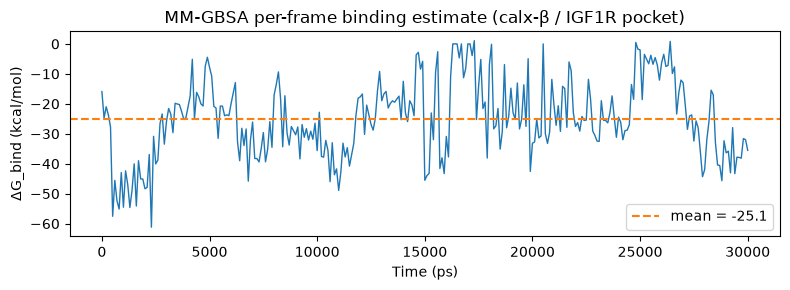


Saved: /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/mmpbsa/mmpbsa_results_manifest.json


In [9]:
def find_results_files(prefix: Path) -> list[Path]:
    candidates = sorted(MMPBSA_DIR.glob(f"{prefix.name}*"))
    if not candidates:
        candidates = sorted(MMPBSA_DIR.rglob("FINAL*"))
    if not candidates:
        candidates = sorted(MD_ROOT.glob(f"{prefix.name}*"))
    return candidates


def parse_final_dat(path: Path) -> dict[str, float]:
    """Parse gmx_MMPBSA FINAL_RESULTS*.dat ΔTOTAL line (Average, SD(Prop.), SD, …)."""
    stats: dict[str, float] = {}
    in_delta = False
    for raw in path.read_text().splitlines():
        line = raw.replace("Δ", "DELTA")
        upper = line.upper()
        if "DELTA" in upper and "COMPLEX" in upper:
            in_delta = True
            continue
        if not in_delta:
            continue
        if not line.strip() or line.startswith("---"):
            if stats:
                break
            continue
        parts = line.split()
        if not parts:
            continue
        if parts[0] == "DELTATOTAL":
            nums = parts[1:]
        elif len(parts) >= 2 and parts[0] == "DELTA" and parts[1] == "TOTAL":
            nums = parts[2:]
        else:
            continue
        if nums:
            stats["delta_total_mean"] = float(nums[0])
        if len(nums) >= 3:
            stats["delta_total_std"] = float(nums[2])  # sample SD
    return stats


def parse_decomp_csv(path: Path) -> pd.DataFrame | None:
    """Per-frame ΔG terms from the 'Delta Energy Terms' block (not complex TOTAL)."""
    if not path.exists():
        return None
    lines = path.read_text().splitlines()
    start = next((i for i, ln in enumerate(lines) if ln.strip() == "Delta Energy Terms"), None)
    if start is None:
        return None
    from io import StringIO

    block = []
    for ln in lines[start + 1 :]:
        if not ln.strip():
            break
        if ln.endswith("Energy Terms") and not ln.startswith("Frame"):
            break
        block.append(ln)
    if len(block) < 2:
        return None
    return pd.read_csv(StringIO("\n".join(block)))


def bootstrap_ci(values: np.ndarray, n_boot: int = 2000, alpha: float = 0.05) -> tuple[float, float]:
    rng = np.random.default_rng(0)
    boots = np.array(
        [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    )
    lo, hi = np.quantile(boots, [alpha / 2, 1 - alpha / 2])
    return float(lo), float(hi)


result_files = find_results_files(RESULTS_PREFIX)
print("Result files:", [p.name for p in result_files[:12]], "…" if len(result_files) > 12 else "")

final_dat = next((p for p in result_files if "FINAL_RESULTS" in p.name and p.suffix == ".dat"), None)
final_csv = next((p for p in result_files if "FINAL_RESULTS" in p.name and p.suffix == ".csv"), None)

summary: dict[str, object] = {"method": MMPBSA_METHOD, "n_frames": int(traj.n_frames)}

if final_dat and final_dat.exists():
    parsed = parse_final_dat(final_dat)
    summary.update(parsed)
    dG = parsed.get("delta_total_mean")
    dG_std = parsed.get("delta_total_std")
    if dG is not None:
        unit = "kcal/mol"  # gmx_MMPBSA default output
        if dG_std is not None:
            print(f"\nΔG_bind = {dG:.2f} ± {dG_std:.2f} {unit}  (gmx_MMPBSA aggregate)")
        else:
            print(f"\nΔG_bind = {dG:.2f} {unit}")
else:
    print("No FINAL_RESULTS_MMPBSA.dat yet — run with RUN_MMPBSA=True.")

if final_csv and final_csv.exists():
    df = parse_decomp_csv(final_csv)
    if df is not None and "TOTAL" in df.columns:
        values = df["TOTAL"].to_numpy(dtype=float)
        mean = float(np.mean(values))
        std = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
        sem = std / np.sqrt(len(values)) if len(values) > 1 else 0.0
        lo, hi = bootstrap_ci(values)
        summary.update(
            {
                "delta_total_mean_csv": mean,
                "delta_total_std_csv": std,
                "delta_total_sem_csv": sem,
                "bootstrap_95_lo": lo,
                "bootstrap_95_hi": hi,
            }
        )
        print(
            f"Per-frame TOTAL: {mean:.2f} ± {std:.2f} kcal/mol (SEM {sem:.2f}); "
            f"bootstrap 95% CI [{lo:.2f}, {hi:.2f}]"
        )
        n = len(values)
        mid = max(1, n // 2)
        summary.update(
            {
                "n_unbound_frames": int(np.sum(values >= 0.0)),
                "delta_total_min": float(np.min(values)),
                "delta_total_max": float(np.max(values)),
                "late_minus_early_kcal": float(np.mean(values[mid:]) - np.mean(values[:mid])),
            }
        )
        if len(getattr(traj, "time", [])) == n:
            time_ps = np.asarray(traj.time, dtype=float)
        elif "Frame #" in df.columns:
            frame = df["Frame #"].to_numpy(dtype=float)
            if len(getattr(traj, "time", [])) > 1:
                dt = float(traj.time[-1] - traj.time[0]) / (len(traj.time) - 1)
                t0 = float(traj.time[0])
            else:
                dt = float(TRJCONV_DT_PS) if TRJCONV_DT_PS else 1.0
                t0 = float(TRJCONV_START_PS)
            time_ps = t0 + (frame - 1.0) * dt
        else:
            time_ps = np.arange(n, dtype=float)
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(time_ps, values, lw=1)
        ax.axhline(mean, color="C1", ls="--", label=f"mean = {mean:.1f}")
        ax.set_xlabel("Time (ps)")
        ax.set_ylabel("ΔG_bind (kcal/mol)")
        ax.set_title("MM-GBSA per-frame binding estimate (calx-β / IGF1R pocket)")
        ax.legend()
        plt.tight_layout()
        plt.show()
        plt.close("all")

t = np.asarray(getattr(traj, "time", []), dtype=float)
if len(t) > 1:
    summary["traj_ps"] = float(t[-1] - t[0])
elif len(t) == 1:
    summary["traj_ps"] = float(t[0])
else:
    summary["traj_ps"] = float(last_mmpbsa_ps) if "last_mmpbsa_ps" in dir() else 0.0

summary["saved_at"] = datetime.now(timezone.utc).isoformat()
summary["source_trajectory"] = str(xtc_for_mmpbsa.resolve())
summary["final_dat"] = str(final_dat.resolve()) if final_dat else None
RESULTS_MANIFEST.write_text(json.dumps(summary, indent=2) + "\n")
print(f"\nSaved: {RESULTS_MANIFEST}")

Re-run the next cell after every MM-GBSA job. It writes the Interpretation section from `summary` (length, mean ΔG, SEM, CI, unbound frames) — not from a fixed 1 ns template.

In [10]:
from IPython.display import Markdown, display


def _kcal(x: float) -> str:
    return f"{x:.2f}"


def _ns_label(traj_ps: float) -> str:
    if traj_ps >= 1000:
        return f"{traj_ps / 1000.0:.1f} ns"
    return f"{traj_ps:.0f} ps"


def write_mmpbsa_interpretation(summary: dict) -> str:
    """Rebuild the Interpretation section from this run's summary (not a fixed 1 ns text)."""
    method = str(summary.get("method", MMPBSA_METHOD)).upper()
    n_frames = int(summary.get("n_frames") or 0)
    traj_ps = float(summary.get("traj_ps") or 0.0)
    length = _ns_label(traj_ps)

    mean = summary.get("delta_total_mean")
    if mean is None:
        mean = summary.get("delta_total_mean_csv")
    std = summary.get("delta_total_std_csv")
    if std is None:
        std = summary.get("delta_total_std")
    sem = summary.get("delta_total_sem_csv")
    lo = summary.get("bootstrap_95_lo")
    hi = summary.get("bootstrap_95_hi")
    n_unbound = summary.get("n_unbound_frames")
    late_drift = summary.get("late_minus_early_kcal")

    if mean is None:
        text = (
            "## Interpretation\n\n"
            "No MM-GBSA totals yet. Set `RUN_MMPBSA = True` and re-run the analysis cell."
        )
        display(Markdown(text))
        return text

    mean = float(mean)
    favorable = mean < 0.0
    ci_ok = lo is not None and hi is not None
    ci_all_neg = bool(ci_ok and float(hi) < 0.0)
    ci_all_pos = bool(ci_ok and float(lo) > 0.0)
    ci_includes_zero = bool(ci_ok and float(lo) <= 0.0 <= float(hi))
    no_unbound = n_unbound is not None and int(n_unbound) == 0
    short = traj_ps < 10_000.0
    strong_ok = traj_ps >= 50_000.0

    if favorable and ci_all_neg and no_unbound:
        if short:
            headline = (
                "The data support a favorable, retained bound pose over this short "
                "trajectory — not a definitive claim of thermodynamically stable "
                "(high-affinity) binding."
            )
        else:
            headline = (
                "The data support a favorable, retained bound pose over this trajectory "
                "— still not a definitive claim of thermodynamically stable "
                "(high-affinity) binding."
            )
    elif favorable and (ci_includes_zero or (n_unbound is not None and int(n_unbound) > 0)):
        headline = (
            "The mean ΔG estimate is favorable, but uncertainty or unbound frames "
            "weaken a retained-pose reading."
        )
    elif not favorable:
        headline = (
            "The data do not support a favorable bound pose on this trajectory "
            "(mean ΔG is not negative)."
        )
    else:
        headline = (
            "The mean ΔG estimate is favorable; treat the result as qualitative "
            "until per-frame statistics are available."
        )

    if favorable:
        q1 = f"**Yes.** Mean **{_kcal(mean)} kcal/mol** (gmx_MMPBSA aggregate, {method})."
    else:
        q1 = f"**No.** Mean **{_kcal(mean)} kcal/mol** (gmx_MMPBSA aggregate, {method})."

    if ci_all_neg and sem is not None:
        q2 = (
            f"**Yes.** Per-frame SEM **{_kcal(float(sem))}** kcal/mol; "
            f"bootstrap 95% CI **[{_kcal(float(lo))}, {_kcal(float(hi))}]** "
            "(entirely &lt; 0)."
        )
    elif ci_all_pos and sem is not None:
        q2 = (
            f"**Yes (unfavorable).** Per-frame SEM **{_kcal(float(sem))}** kcal/mol; "
            f"bootstrap 95% CI **[{_kcal(float(lo))}, {_kcal(float(hi))}]** "
            "(entirely &gt; 0)."
        )
    elif ci_includes_zero and sem is not None:
        q2 = (
            f"**No.** Per-frame SEM **{_kcal(float(sem))}** kcal/mol; "
            f"bootstrap 95% CI **[{_kcal(float(lo))}, {_kcal(float(hi))}]** "
            "includes 0."
        )
    elif sem is not None:
        q2 = f"Per-frame SEM **{_kcal(float(sem))}** kcal/mol; CI not computed."
    else:
        q2 = "Per-frame SEM / bootstrap CI not available (no Delta Energy Terms CSV)."

    if n_unbound is None:
        q3 = "Per-frame totals not available."
    elif no_unbound:
        q3 = (
            f"**No** on this {length} window — per-frame totals stay negative "
            f"({n_frames} frames)."
        )
    else:
        q3 = f"**Yes.** {int(n_unbound)} of {n_frames} frames have ΔG ≥ 0."

    if short:
        q4 = (
            f"**No.** {length} is too short; MM-GBSA is approximate and usually "
            "**too favorable** vs experiment."
        )
    else:
        q4 = (
            "**No.** MM-GBSA is approximate and usually **too favorable** vs experiment; "
            "this is not a calibrated Kd."
        )

    if no_unbound and favorable:
        read = (
            f"calx-β **does not show MM-GBSA evidence of dissociation** over ~{length}, "
            "and the complex remains **energetically preferred** relative to separated "
            "receptor + ligand in the implicit-solvent model. That is **consistent with** "
            "Notebook 1’s “retained binding” heuristic (pose + contacts). It is **not** a "
            "calibrated Kd, kon/koff, or a claim that the pose is the global free-energy minimum."
        )
    elif n_unbound is not None and int(n_unbound) > 0:
        read = (
            f"Some frames have ΔG ≥ 0 ({int(n_unbound)}/{n_frames}). "
            "Do not treat this as a retained bound pose without inspecting those frames "
            "and Notebook 1 RMSD/contacts."
        )
    else:
        read = (
            "Read the table above together with Notebook 1 RMSD and pocket contacts. "
            "MM-GBSA is not a calibrated Kd."
        )

    if late_drift is not None and float(late_drift) > 2.0:
        read += (
            f" Late-minus-early mean ΔG is **+{_kcal(float(late_drift))} kcal/mol** "
            "(less favorable later in the run)."
        )

    if short:
        sampling = (
            f"This trajectory is **~{length}** ({n_frames} frames). Prefer **≥10 ns** "
            "before treating the mean as more than **qualitative** support, and "
            "**≥50–100 ns** (plus experiment) before a strong stability/affinity claim."
        )
    elif not strong_ok:
        sampling = (
            f"This trajectory is **~{length}** ({n_frames} frames). That is enough for "
            "**qualitative** support if ΔG stays negative. Prefer **≥50–100 ns** "
            "(plus experiment) before a strong stability/affinity claim."
        )
    else:
        sampling = (
            f"This trajectory is **~{length}** ({n_frames} frames). Length is no longer "
            "the main limit; MM-GBSA is still approximate. Experiment is required for a "
            "strong affinity claim."
        )

    if std is not None and sem is not None:
        spread = (
            f"- **Spread (SD ~{float(std):.0f} kcal/mol, SEM ~{float(sem):.1f}):** "
            f"frame-to-frame fluctuation is large; the **mean** is well determined on "
            f"{n_frames} frames, but the **physical** uncertainty is larger than SEM "
            "(force field, GB model, missing entropy, truncated pocket).\n"
        )
    else:
        spread = "- **Spread:** per-frame SD/SEM not available for this run.\n"

    text = f"""## Interpretation

### Verdict (this {length} production run)

**{headline}**

| Question | Answer from this run |
|----------|----------------------|
| Is estimated ΔG_bind favorable (negative)? | {q1} |
| Is that distinguishable from zero? | {q2} |
| Do frames flip to unbound (ΔG ≥ 0)? | {q3} |
| Does that prove stable high-affinity binding? | {q4} |

**Read this as:** {read}

### What would *support* stable binding more strongly

- Production MD **≥10–100 ns** with the same protocol, still **negative ΔG** and **no late drift** toward 0.
- Notebook 1: ligand RMSD stays in the pocket and receptor contacts remain high over that longer window.
- Optional: MM-PBSA and/or per-residue decomp (`RUN_DECOMP = True`) agreeing on a persistent interface.
- Experiment (binding assay) if the scientific claim is biological affinity.

### What would *weaken or reject* the hypothesis

- Mean ΔG near **0** or **positive**, or a 95% CI that **includes 0**.
- Per-frame ΔG **trending upward** (less favorable) or **crossing to unbound** in the second half of the run.
- Large ligand RMSD / loss of pocket contacts in Notebook 1, even if early frames look favorable.

### How to read the numbers (same protocol only)

- **Sign:** more negative → more favorable *estimated* binding in this GB model.
- **Magnitude ({_kcal(mean)} kcal/mol):** typical MM-GBSA overbinding for a peptide-sized ligand; **do not** convert to experimental Kd.
{spread}- Compare **poses / mutants / run lengths** only when force field, `igb`, salt, and frame selection match.

### Sampling caveat

{sampling}
"""
    display(Markdown(text))
    out = MMPBSA_DIR / "mmpbsa_interpretation.md"
    out.write_text(text)
    print(f"Wrote {out}")
    return text


write_mmpbsa_interpretation(summary)

## Interpretation

### Verdict (this 30.0 ns production run)

**The mean ΔG estimate is favorable, but uncertainty or unbound frames weaken a retained-pose reading.**

| Question | Answer from this run |
|----------|----------------------|
| Is estimated ΔG_bind favorable (negative)? | **Yes.** Mean **-25.08 kcal/mol** (gmx_MMPBSA aggregate, GBSA). |
| Is that distinguishable from zero? | **Yes.** Per-frame SEM **0.74** kcal/mol; bootstrap 95% CI **[-26.60, -23.64]** (entirely &lt; 0). |
| Do frames flip to unbound (ΔG ≥ 0)? | **Yes.** 10 of 301 frames have ΔG ≥ 0. |
| Does that prove stable high-affinity binding? | **No.** MM-GBSA is approximate and usually **too favorable** vs experiment; this is not a calibrated Kd. |

**Read this as:** Some frames have ΔG ≥ 0 (10/301). Do not treat this as a retained bound pose without inspecting those frames and Notebook 1 RMSD/contacts. Late-minus-early mean ΔG is **+6.49 kcal/mol** (less favorable later in the run).

### What would *support* stable binding more strongly

- Production MD **≥10–100 ns** with the same protocol, still **negative ΔG** and **no late drift** toward 0.
- Notebook 1: ligand RMSD stays in the pocket and receptor contacts remain high over that longer window.
- Optional: MM-PBSA and/or per-residue decomp (`RUN_DECOMP = True`) agreeing on a persistent interface.
- Experiment (binding assay) if the scientific claim is biological affinity.

### What would *weaken or reject* the hypothesis

- Mean ΔG near **0** or **positive**, or a 95% CI that **includes 0**.
- Per-frame ΔG **trending upward** (less favorable) or **crossing to unbound** in the second half of the run.
- Large ligand RMSD / loss of pocket contacts in Notebook 1, even if early frames look favorable.

### How to read the numbers (same protocol only)

- **Sign:** more negative → more favorable *estimated* binding in this GB model.
- **Magnitude (-25.08 kcal/mol):** typical MM-GBSA overbinding for a peptide-sized ligand; **do not** convert to experimental Kd.
- **Spread (SD ~13 kcal/mol, SEM ~0.7):** frame-to-frame fluctuation is large; the **mean** is well determined on 301 frames, but the **physical** uncertainty is larger than SEM (force field, GB model, missing entropy, truncated pocket).
- Compare **poses / mutants / run lengths** only when force field, `igb`, salt, and frame selection match.

### Sampling caveat

This trajectory is **~30.0 ns** (301 frames). That is enough for **qualitative** support if ΔG stays negative. Prefer **≥50–100 ns** (plus experiment) before a strong stability/affinity claim.


Wrote /workspace/repos/tomo_2026b/md/data/md_calx_3qqu/mmpbsa/mmpbsa_interpretation.md


'## Interpretation\n\n### Verdict (this 30.0 ns production run)\n\n**The mean ΔG estimate is favorable, but uncertainty or unbound frames weaken a retained-pose reading.**\n\n| Question | Answer from this run |\n|----------|----------------------|\n| Is estimated ΔG_bind favorable (negative)? | **Yes.** Mean **-25.08 kcal/mol** (gmx_MMPBSA aggregate, GBSA). |\n| Is that distinguishable from zero? | **Yes.** Per-frame SEM **0.74** kcal/mol; bootstrap 95% CI **[-26.60, -23.64]** (entirely &lt; 0). |\n| Do frames flip to unbound (ΔG ≥ 0)? | **Yes.** 10 of 301 frames have ΔG ≥ 0. |\n| Does that prove stable high-affinity binding? | **No.** MM-GBSA is approximate and usually **too favorable** vs experiment; this is not a calibrated Kd. |\n\n**Read this as:** Some frames have ΔG ≥ 0 (10/301). Do not treat this as a retained bound pose without inspecting those frames and Notebook 1 RMSD/contacts. Late-minus-early mean ΔG is **+6.49 kcal/mol** (less favorable later in the run).\n\n### What wou

In [12]:
! jupyter nbconvert --to html --no-input --embed-images igf1r3qqu_calxbeta_pbsa_gbsa_md.ipynb

[NbConvertApp] Converting notebook igf1r3qqu_calxbeta_pbsa_gbsa_md.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 371062 bytes to igf1r3qqu_calxbeta_pbsa_gbsa_md.html
